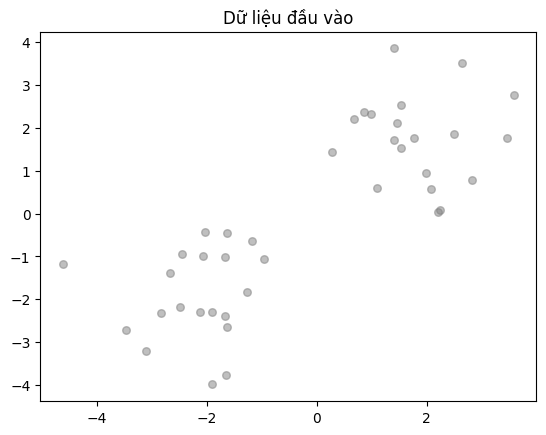

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Tạo dữ liệu mẫu gồm 2 cụm để test (Giống Demo 2)
np.random.seed(42)
cluster1 = np.random.randn(20, 2) + [2, 2]
cluster2 = np.random.randn(20, 2) + [-2, -2]
data = np.vstack([cluster1, cluster2])

def plot_data(data):
    plt.scatter(data[:, 0], data[:, 1], c='gray', s=30, alpha=0.5)
    plt.title("Dữ liệu đầu vào")
    plt.show()

plot_data(data)

In [2]:
def gaussian_kernel_weight(dist, h):
    # K(u) = exp(-0.5 * u^2)
    return np.exp(-0.5 * (dist / h)**2)

def mean_shift_step(point, data, h, kernel_type='gaussian'):
    dists = np.linalg.norm(point - data, axis=1)
    
    if kernel_type == 'gaussian':
        weights = gaussian_kernel_weight(dists, h)
    else: # Flat kernel
        weights = (dists < h).astype(float)
        
    if np.sum(weights) == 0:
        return point
    
    # Công thức m(x) [cite: 132]
    new_point = np.sum(data * weights[:, np.newaxis], axis=0) / np.sum(weights)
    return new_point

def run_mean_shift(data, h, kernel_type='gaussian', eps=1e-4):
    shifted_points = np.copy(data)
    iters_count = []
    
    for i in range(len(shifted_points)):
        it = 0
        curr = shifted_points[i]
        while True:
            it += 1
            next_p = mean_shift_step(curr, data, h, kernel_type)
            if np.linalg.norm(next_p - curr) < eps or it > 100:
                shifted_points[i] = next_p
                iters_count.append(it)
                break
            curr = next_p
    return shifted_points, iters_count

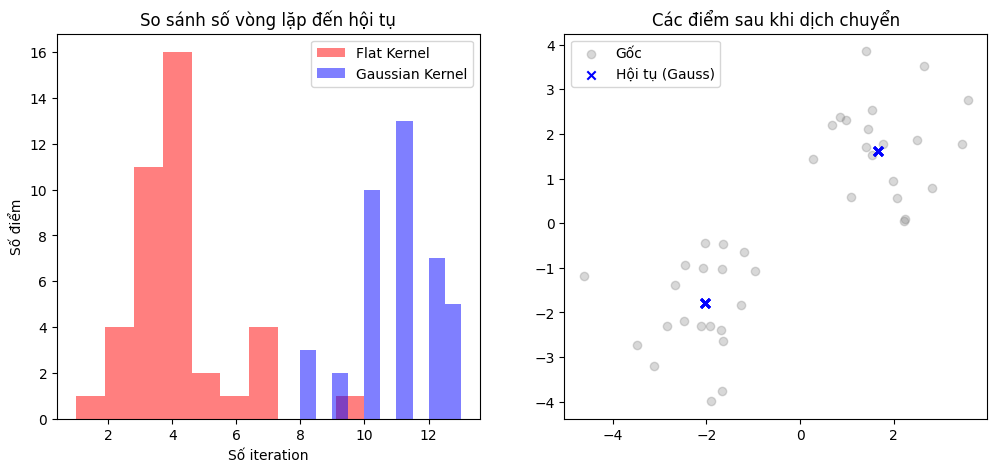

Số iteration trung bình (Flat): 4.00
Số iteration trung bình (Gaussian): 10.85


In [3]:
h_val = 1.5

# Chạy cả 2 loại kernel
points_flat, iters_flat = run_mean_shift(data, h_val, kernel_type='flat')
points_gauss, iters_gauss = run_mean_shift(data, h_val, kernel_type='gaussian')

# Vẽ Histogram so sánh [cite: 134]
plt.figure(figsize=(12, 5))
plt.subplot(121)
plt.hist(iters_flat, bins=10, alpha=0.5, label='Flat Kernel', color='red')
plt.hist(iters_gauss, bins=10, alpha=0.5, label='Gaussian Kernel', color='blue')
plt.xlabel("Số iteration")
plt.ylabel("Số điểm")
plt.legend()
plt.title("So sánh số vòng lặp đến hội tụ")

plt.subplot(122)
plt.scatter(data[:,0], data[:,1], c='gray', alpha=0.3, label='Gốc')
plt.scatter(points_gauss[:,0], points_gauss[:,1], c='blue', marker='x', label='Hội tụ (Gauss)')
plt.legend()
plt.title("Các điểm sau khi dịch chuyển")
plt.show()

print(f"Số iteration trung bình (Flat): {np.mean(iters_flat):.2f}")
print(f"Số iteration trung bình (Gaussian): {np.mean(iters_gauss):.2f}")

In [4]:
def kde_2d(data, h, grid_res=50):
    # Tạo lưới (grid) [cite: 137]
    x_min, x_max = data[:, 0].min() - 1, data[:, 0].max() + 1
    y_min, y_max = data[:, 1].min() - 1, data[:, 1].max() + 1
    
    x_grid = np.linspace(x_min, x_max, grid_res)
    y_grid = np.linspace(y_min, y_max, grid_res)
    X, Y = np.meshgrid(x_grid, y_grid)
    grid_points = np.vstack([X.ravel(), Y.ravel()]).T
    
    Z = np.zeros(len(grid_points))
    n = len(data)
    
    for i, p in enumerate(grid_points):
        dists = np.linalg.norm(p - data, axis=1)
        # Tính f(x) dùng Gaussian kernel [cite: 136]
        kernel_vals = (1/(2*np.pi)) * np.exp(-0.5 * (dists/h)**2)
        Z[i] = (1 / (n * h**2)) * np.sum(kernel_vals)
        
    return X, Y, Z.reshape(grid_res, grid_res)

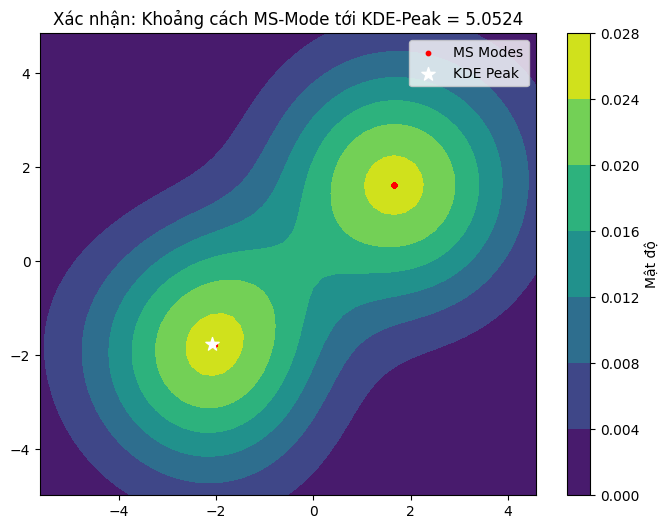

In [5]:
X, Y, Z = kde_2d(data, h_val)

# Tìm tọa độ đỉnh cao nhất của KDE
idx = np.unravel_index(np.argmax(Z), Z.shape)
kde_peak = np.array([X[idx], Y[idx]])

# Lấy một mode tiêu biểu từ Mean-Shift
ms_mode = points_gauss[0] 

dist_check = np.linalg.norm(ms_mode - kde_peak)

plt.figure(figsize=(8, 6))
plt.contourf(X, Y, Z, cmap='viridis')
plt.colorbar(label='Mật độ')
plt.scatter(points_gauss[:, 0], points_gauss[:, 1], color='red', s=10, label='MS Modes')
plt.scatter(kde_peak[0], kde_peak[1], color='white', marker='*', s=100, label='KDE Peak')
plt.title(f"Xác nhận: Khoảng cách MS-Mode tới KDE-Peak = {dist_check:.4f}")
plt.legend()
plt.show()

if dist_check < 0.1 * h_val:
    print("Xác nhận thành công: Mode nằm trong khoảng 0.1h từ đỉnh KDE!")